In [2]:
import cv2 as cv
import numpy as np

# Translation

In [3]:
image = cv.imread("../data/colors.jpg")
cv.imshow("original", image)
cv.waitKey(0)

-1

prepare translation matrix to shift down and right

In [4]:
M = np.float32([
    [1,0,25], #shift for x by 25 pixels
    [0,1,50]  #shift for y by 50 pixels
])
shifted = cv.warpAffine(image, M, (image.shape[1], image.shape[0]))
cv.imshow("Shifted Down and Right", shifted)
cv.waitKey(0)


-1

Shift up and left

In [5]:
M = np.float32([
    [1,0,- 25], #shift for x by 25 pixels
    [0,1,- 50]  #shift for y by 50 pixels
])
shifted = cv.warpAffine(image, M, (image.shape[1], image.shape[0]))
cv.imshow("Shifted Up and Left", shifted)
cv.waitKey(0)

-1

Make a translation function

In [6]:
def translate_image(image, x, y): 
    M = np.float32([
        [1,0,x], #shift for x by x pixels
        [0,1,y]  #shift for y by y pixels
    ])
    shifted = cv.warpAffine(image, M, (image.shape[1], image.shape[0]))
    return shifted

In [7]:
shifted = translate_image(image, -50, 20)
cv.imshow("Shifted Up and Left", shifted)
cv.waitKey(0)

-1

# Rotation

In [8]:
(h, w) = image.shape[:2]
center = (w // 2, h // 2)
M = cv.getRotationMatrix2D(center, 45, 0.5)
rotated = cv.warpAffine(image, M, (w, h))
cv.imshow("Rotated by 45 degrees", rotated)
cv.waitKey(0)

-1

Write a function for rotation

In [9]:
def rotate_image(image, angle, scale=1.0):
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv.getRotationMatrix2D(center, angle, scale)
    rotated = cv.warpAffine(image, M, (w, h))
    return rotated

In [10]:
rotated = rotate_image(image, 30)
cv.imshow("Rotated by 30 degrees", rotated)
cv.waitKey(0)

-1

# Resizing

In [11]:
h = image.shape[0]
w = image.shape[1]
r = 50.0 / h
print(r)
# new dimensions for the resized image
dim = (int(w * r), 50) # (w,h)
resized = cv.resize(image, dim, interpolation=cv.INTER_AREA)
cv.imshow("Resized (Height)", resized)
cv.waitKey(0)

0.09259259259259259


-1

In [12]:
import imutils

In [13]:
resized = imutils.resize(image, width=100)
cv.imshow("Resized with imutils", resized)
cv.waitKey(0)

-1

Write a function called display_image

In [14]:
def display_image(title, image):
    cv.imshow(title, image)
    cv.waitKey(0)

# Flipping

In [15]:
flipped = cv.flip(image, 1)
display_image("Flipped Horizontally", flipped)

In [16]:
flipped = cv.flip(image, 0)
display_image("Flipped Vertically", flipped)

In [17]:
flipped = cv.flip(image, -1)
display_image("Flipped Vertically and horizontally", flipped)

# Cropping

In [18]:
cropped = image [30:120, 240:335]
display_image("Cropped", cropped)

# Arithmetics Operations

change colors

In [19]:
M = np.ones(image.shape, dtype="uint8") *100 # arrays of 50s with same dimensions as image
subtracted = cv.subtract(image, M)
display_image("Subtracted", subtracted)

# Bitwize Operations

In [20]:
rectangle = np.zeros((300, 300), dtype="uint8")
cv.rectangle(rectangle, (25, 25), (275, 275), 255, -1)
cv.imshow("Rectangle", rectangle)

circle = np.zeros((300, 300), dtype="uint8")
cv.circle(circle, (150, 150), 150, 255, -1)
cv.imshow("Circle", circle)

cv.waitKey(0)

-1

rectangle inside the circle

In [ ]:
bitwiseAnd = cv.bitwise_and(rectangle, circle)
display_image("Bitwise AND", bitwiseAnd)

In [22]:
bitwiseOr = cv.bitwise_or(rectangle, circle)
display_image("Bitwise OR", bitwiseOr)

In [23]:
bitwiseXor = cv.bitwise_xor(rectangle, circle)
display_image("Bitwise XOR", bitwiseXor)

In [24]:
bitwiseNot = cv.bitwise_not(rectangle)
display_image("Bitwise NOT", bitwiseNot)

# Masking 

it keeps the pixels which has multiplication of the numbers = non zeros

In [27]:
mask = np.zeros (image.shape[:2], dtype="uint8")
(cX, cY) = (image.shape[1] // 2, image.shape[0] // 2)
cv.rectangle(mask, (cX -75, cY -75), (cX +75, cY +75), 255, -1)
display_image("Mask", mask)


In [28]:
masked = cv.bitwise_and(image, image, mask=mask)
display_image("Masked Image", masked)

# Color Spaces

In [ ]:
gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
display_image("Grayscale", gray)

In [32]:
hsv = cv.cvtColor(image, cv.COLOR_BGR2HSV)
display_image("HSV", hsv)

In [33]:
lab = cv.cvtColor(image, cv.COLOR_BGR2LAB)
display_image("LAB", lab)

# Histograms

shows distribution of pixels intensity

In [36]:
import matplotlib.pyplot as plt 

image = cv.imread("../data/grayscale_image.jpg")
image = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
display_image("Grayscale", image)

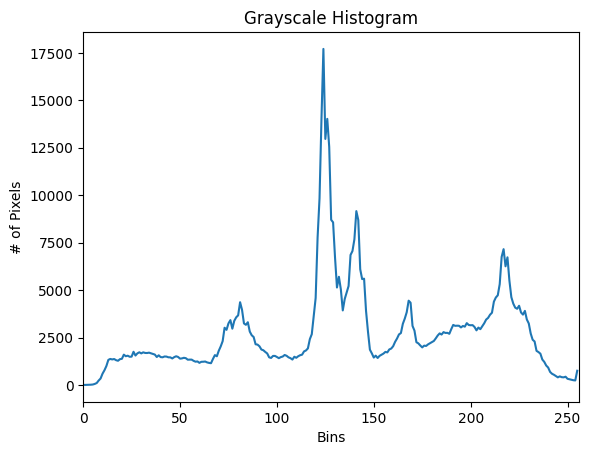

In [37]:
#calculate the histogram for the grayscale image
#  array of images, 1st channel, mask, histogram size, range of pixel values
hist = cv.calcHist([image], [0], None, [256], [0, 256])
plt.figure()
plt.title("Grayscale Histogram")
plt.xlabel("Bins")
plt.ylabel("# of Pixels")
plt.plot(hist)
plt.xlim([0, 256])
plt.show()

Histogram for colored image

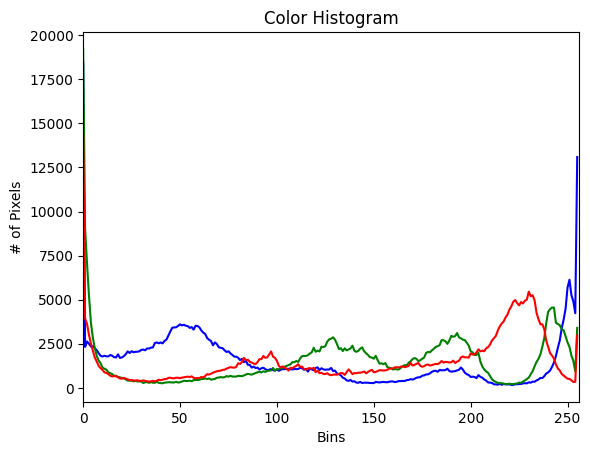

In [38]:
image = cv.imread("../data/colors.jpg")
channels= cv.split(image)
colors = ("b", "g", "r")
plt.figure()
plt.title("Color Histogram")
plt.xlabel("Bins")
plt.ylabel("# of Pixels")

for (channel, color) in zip(channels, colors):
    hist = cv.calcHist([channel], [0], None, [256], [0, 256])
    plt.plot(hist, color=color)
    plt.xlim([0, 256])
plt.show()


# Smoothing and Blur

In [39]:
image = cv.imread("../data/colors.jpg")
blurred = np.hstack(
    [
        cv.blur(image, (3, 3)),
        cv.blur(image, (5, 5)),
        cv.blur(image, (7, 7))
    ]
)
display_image("Blurred", blurred)

In [ ]:
blurred = np.hstack(
    [
        cv.GaussianBlur(image, (3, 3), 0), # 0 is the stddev for the Gaussian kernel, if 0 is given, it is calculated from the kernel size
        cv.GaussianBlur(image, (5, 5), 0),
        cv.GaussianBlur(image, (7, 7), 0)
    ]
)
display_image("Gaussian Blurred", blurred)

In [42]:
blurred = np.hstack(
    [
        cv.medianBlur(image, 3), 
        cv.medianBlur(image, 5),
        cv.medianBlur(image, 7)
    ]
)
display_image("Median Blurred", blurred)